# AgriProyecto del Segundo Parcial
## Clasificación del Riesgo de Inundación por Parroquia en Zonas Lluviosas del Ecuador

# URL : https://krissie2005.pythonanywhere.com/

Este notebook está organizado por fases: carga de datos, limpieza/unificación, ingeniería de variables, construcción de la etiqueta, modelado, evaluación y exportación de resultados.

## Fuentes de datos y organización del proyecto

Los insumos del proyecto se guardan en la carpeta data/raw/, separando los archivos originales (sin procesar) de los archivos generados (data/processed/). A continuación se detalla el origen y uso de cada fuente:

1) Precipitación (ecu-rainfall-subnat-full)

Archivo/carpeta: ecu-rainfall-subnat-full.csv

Fuente: Humanitarian Data Exchange (HDX)
https://data.humdata.org/dataset/ecu-rainfall-subnational

Uso en el proyecto: variables de precipitación (por ejemplo, acumulados/promedios por años) para representar el componente climático asociado al riesgo.

2) Eventos históricos de lluvia/inundación

Archivo: Base_Eventos_2010_2023_eventos_catálogo (Excel)

Fuente: HydroShare
https://www.hydroshare.org/resource/e7a4a44bed0d408b958b682b8fa237c3/

Uso en el proyecto: variable de evidencia histórica (por ejemplo TIENE_EVENTO_LLUVIA) para validar/fortalecer la construcción del riesgo.

3) Densidad poblacional

Archivo: Densidad poblacional INEC.xlsx

Fuente: INEC – Censo de Población y Vivienda
https://www.ecuadorencifras.gob.ec/censo-de-poblacion-y-vivienda/

Uso en el proyecto: variables demográficas como población, superficie y densidad para representar vulnerabilidad/exposición humana.

4) Población urbano/rural y total por parroquia

Archivo: 1_POBL_PROV_CANT_PARR_AREA.xlsx

Fuente: INEC (misma plataforma institucional)

Uso en el proyecto: cálculo de PORC_URBANO y PORC_RURAL para caracterizar composición territorial.

5) Límites administrativos de parroquias (Shapefile)

Carpeta: GeoJson parroquias/ (contiene .shp, .dbf, .shx, etc.)

Fuente: INEC – Geoportal / Clasificador Geográfico Estadístico
https://www.ecuadorencifras.gob.ec/documentos/web-inec/Geografia_Estadistica/Micrositio_geoportal/index.html

Uso en el proyecto: base geográfica oficial para unir predicciones y para generar el “puente” hacia DPA_PARROQ.

6) Modelo de elevación / Topografía (GeoTIFF)

Carpeta: GeoTIFF/ (múltiples tiles) + archivos unidos (GeoTifCompleto...tif)

Fuente: USGS EarthExplorer
https://earthexplorer.usgs.gov/

Uso en el proyecto: construcción de variables topográficas como altitud y pendiente (DEM → pendiente), integradas por parroquia.

7) Red hidrográfica (ríos)

Carpeta: HydroRIVERS_v10_sa.gdb

Fuente: HydroSHEDS – HydroRIVERS
https://www.hydrosheds.org/products/hydrorivers

Uso en el proyecto: se descargó Sudamérica y luego se filtraron los ríos que intersectan Ecuador para calcular DIST_RIO_M (distancia mínima a ríos).

### Importamos las librerías que usaremos

In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.svm import SVC

Cargamos los archivos que vamos a procesar en esta etapa:

In [ ]:
ruta_densidad = "../data/raw/Densidad poblacional INEC.xlsx"
ruta_area = "../data/raw/1_POBL_PROV_CANT_PARR_AREA.xlsx"

En esta sección se cargan los datos de densidad poblacional obtenidos del INEC.
Estos datos contienen información a nivel de provincia, cantón y parroquia, incluyendo población, superficie y densidad.

In [ ]:
df_densidad = pd.read_excel(ruta_densidad)

# Renombrar a nombres estándar
df_densidad = df_densidad.rename(columns={
    "Código": "CODIGO",
    "Nombre de provincia": "PROVINCIA",
    "Nombre de canton": "CANTON",
    "Nombre de parroquia": "PARROQUIA",
    "Población": "POBLACION",
    "Superficie de la parroquia (km2)": "SUPERFICIE_KM2",
    "Densidad Poblacional": "DENSIDAD"
})

# Limpieza de texto 
for col in ["PROVINCIA", "CANTON", "PARROQUIA"]:
    df_densidad[col] = df_densidad[col].astype(str).str.strip().str.upper()

print(df_densidad.head())

   CODIGO PROVINCIA  CANTON       PARROQUIA  POBLACION  SUPERFICIE_KM2  \
0   10150     AZUAY  CUENCA          CUENCA     331888           70.59   
1   10151     AZUAY  CUENCA           BAÑOS      16851          326.71   
2   10152     AZUAY  CUENCA           CUMBE       5546           70.84   
3   10153     AZUAY  CUENCA         CHAUCHA       1297          313.31   
4   10154     AZUAY  CUENCA  CHECA (JIDCAY)       2741           62.81   

      DENSIDAD  
0  4701.629126  
1    51.577852  
2    78.289102  
3     4.139670  
4    43.639548  


En esta parte se procesa el archivo 1_POBL_PROV_CANT_PARR_AREA.xlsx, que no viene como una tabla “limpia”, sino con títulos y filas mezcladas (formato tipo reporte).

El objetivo es construir un DataFrame (df_area) con esta estructura:

* PROVINCIA, CANTON, PARROQUIA

* URBANO, RURAL, TOTAL

para luego unirlo con el dataset de densidad poblacional.

In [ ]:
ruta_area = "../data/raw/1_POBL_PROV_CANT_PARR_AREA.xlsx"

raw = pd.read_excel(ruta_area, header=None)

fila_header = raw.index[raw.eq("Nombre del Cantón").any(axis=1)][0]
fila_datos = fila_header + 2  # los datos empiezan 2 filas después

# Tomar columnas típicas del INEC: provincia, cantón, parroquia, urbano, rural, total
df = raw.iloc[fila_datos:, [1, 2, 3, 4, 5, 6]].copy()
df.columns = ["PROVINCIA_RAW", "CANTON_RAW", "PARROQUIA_RAW", "URBANO", "RURAL", "TOTAL"]

df["PROVINCIA"] = df["PROVINCIA_RAW"].ffill()

canton_header = df["CANTON_RAW"].where(df["PARROQUIA_RAW"].isna())
df["CANTON"] = canton_header.ffill()

df["PARROQUIA"] = df["PARROQUIA_RAW"]

df = df[df["PARROQUIA"].notna()].copy()

df = df[df["PARROQUIA"].astype(str).str.strip().str.upper() != "TOTAL"].copy()

for col in ["URBANO", "RURAL", "TOTAL"]:
    df[col] = df[col].replace("-", 0)
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ARREGLO: si al inicio de una provincia el cantón quedó vacío, la primera parroquia del bloque inicial y se copia hacia abajo
df["CANTON"] = df["CANTON"].replace(["NAN", "nan", "", " "], np.nan)

def fix_canton(grp):
    if pd.isna(grp["CANTON"].iloc[0]):
        primer_canton = grp["PARROQUIA"].iloc[0]  # llenar solo hasta que aparezca el primer cantón válido
        grp["CANTON"] = grp["CANTON"].fillna(primer_canton)
    grp["CANTON"] = grp["CANTON"].ffill()
    return grp

df = df.groupby("PROVINCIA", group_keys=False).apply(fix_canton)

# Limpieza final de texto para unir luego
for col in ["PROVINCIA", "CANTON", "PARROQUIA"]:
    df[col] = df[col].astype(str).str.strip().str.upper()

df_area = df[["PROVINCIA", "CANTON", "PARROQUIA", "URBANO", "RURAL", "TOTAL"]].copy()

# Verificación
print(df_area.head(25))
print("\nCantones vacíos:", df_area["CANTON"].isna().sum())

   PROVINCIA                 CANTON                 PARROQUIA  URBANO  RURAL  \
12     AZUAY  CAMILO PONCE ENRIQUEZ     CAMILO PONCE ENRIQUEZ    4903  12501   
13     AZUAY  CAMILO PONCE ENRIQUEZ       EL CARMEN DE PIJILI       0   4594   
16     AZUAY              CHORDELEG                 CHORDELEG    4209   2578   
17     AZUAY              CHORDELEG                  LA UNION       0   1896   
18     AZUAY              CHORDELEG     LUIS GALARZA ORELLANA       0   1494   
19     AZUAY              CHORDELEG                 PRINCIPAL       0   1331   
20     AZUAY              CHORDELEG      SAN MARTIN DE PUZHIO       0   1069   
23     AZUAY                 CUENCA                     BAÑOS       0  16851   
24     AZUAY                 CUENCA                   CHAUCHA       0   1297   
25     AZUAY                 CUENCA            CHECA (JIDCAY)       0   2741   
26     AZUAY                 CUENCA                CHIQUINTAD       0   4826   
27     AZUAY                 CUENCA     

c:\Users\USER\anaconda3\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
C:\Users\USER\AppData\Local\Temp\ipykernel_10516\212360703.py:33: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace("-", 0)
C:\Users\USER\AppData\Local\Temp\ipykernel_10516\212360703.py:52: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df

Vamos a proceder a unir los 2 datas, del archivo "1_POBL_PROV_CANT_PARR_AREA.xlsx" obtener los datos de porcentajes urbanos y rurales para luego unirlos al archivo de "Densidad Poblacional"

In [6]:
df_final = pd.merge(
    df_densidad,
    df_area,
    on=["PROVINCIA", "CANTON", "PARROQUIA"],
    how="left"
)
print(df_final.head())  

   CODIGO PROVINCIA  CANTON       PARROQUIA  POBLACION  SUPERFICIE_KM2  \
0   10150     AZUAY  CUENCA          CUENCA     331888           70.59   
1   10151     AZUAY  CUENCA           BAÑOS      16851          326.71   
2   10152     AZUAY  CUENCA           CUMBE       5546           70.84   
3   10153     AZUAY  CUENCA         CHAUCHA       1297          313.31   
4   10154     AZUAY  CUENCA  CHECA (JIDCAY)       2741           62.81   

      DENSIDAD    URBANO    RURAL     TOTAL  
0  4701.629126  329928.0   1960.0  331888.0  
1    51.577852       0.0  16851.0   16851.0  
2    78.289102       0.0   5546.0    5546.0  
3     4.139670       0.0   1297.0    1297.0  
4    43.639548       0.0   2741.0    2741.0  


Calculamos el porcentaje Urbano Y Rural de cada zona

In [ ]:
df_final["PORC_URBANO"] = np.where(
    df_final["TOTAL"].notna() & (df_final["TOTAL"] > 0),
    (df_final["URBANO"] / df_final["TOTAL"]) * 100,
    np.nan
)

df_final["PORC_RURAL"] = np.where(
    df_final["TOTAL"].notna() & (df_final["TOTAL"] > 0),
    (df_final["RURAL"] / df_final["TOTAL"]) * 100,
    np.nan
)

df_final["PORC_URBANO"] = df_final["PORC_URBANO"].round(2)
df_final["PORC_RURAL"] = df_final["PORC_RURAL"].round(2)

In [8]:
print(df_final[["PROVINCIA", "CANTON", "PARROQUIA", "URBANO", "RURAL", "TOTAL", "PORC_URBANO", "PORC_RURAL"]].head(20) )

   PROVINCIA  CANTON                 PARROQUIA    URBANO    RURAL     TOTAL  \
0      AZUAY  CUENCA                    CUENCA  329928.0   1960.0  331888.0   
1      AZUAY  CUENCA                     BAÑOS       0.0  16851.0   16851.0   
2      AZUAY  CUENCA                     CUMBE       0.0   5546.0    5546.0   
3      AZUAY  CUENCA                   CHAUCHA       0.0   1297.0    1297.0   
4      AZUAY  CUENCA            CHECA (JIDCAY)       0.0   2741.0    2741.0   
5      AZUAY  CUENCA                CHIQUINTAD       0.0   4826.0    4826.0   
6      AZUAY  CUENCA                    LLACAO       0.0   5342.0    5342.0   
7      AZUAY  CUENCA                 MOLLETURO       0.0   7166.0    7166.0   
8      AZUAY  CUENCA                     NULTI       0.0   4324.0    4324.0   
9      AZUAY  CUENCA  OCTAVIO CORDERO PALACIOS       0.0   2271.0    2271.0   
10     AZUAY  CUENCA                    PACCHA       0.0   6467.0    6467.0   
11     AZUAY  CUENCA                   QUINGEO      

### Guardamos el archivo nuevo con la Densidad Poblacional y la Proporción Rural y Urbana

In [9]:
ruta_salida = "../data/processed/densidadPob_ProporcionUrbRur.csv"

df_final.to_csv(ruta_salida, index=False, encoding="utf-8-sig")

print("Archivo guardado correctamente en:")
print(ruta_salida)

Archivo guardado correctamente en:
../data/processed/densidadPob_ProporcionUrbRur.csv


#### Cargamos la data de "ecu-rainfall-subnat-full" para obtener la precipitación anual

In [10]:
ruta_lluvia = "../data/raw/ecu-rainfall-subnat-full.csv"

df_lluvia = pd.read_csv(ruta_lluvia)

print(df_lluvia.head())
print(df_lluvia.columns)


         date  adm_level  adm_id PCODE  n_pixels        rfh     rfh_avg  \
0  1981-01-01          1    1136  EC02     128.0  15.796875   50.360676   
1  1981-01-11          1    1136  EC02     128.0  83.226560   60.759377   
2  1981-01-21          1    1136  EC02     128.0  59.664062   66.944270   
3  1981-02-01          1    1136  EC02     128.0  98.632810   88.209630   
4  1981-02-11          1    1136  EC02     128.0  82.773440  100.585160   

         r1h    r1h_avg  r3h  r3h_avg        rfq        r1q  r3q version  
0        NaN        NaN  NaN      NaN   37.56615        NaN  NaN   final  
1        NaN        NaN  NaN      NaN  134.16576        NaN  NaN   final  
2  158.68750  178.06432  NaN      NaN   89.88077   89.41529  NaN   final  
3  241.52344  215.91328  NaN      NaN  111.18251  111.59285  NaN   final  
4  241.07031  255.73906  NaN      NaN   83.13047   94.37416  NaN   final  
Index(['date', 'adm_level', 'adm_id', 'PCODE', 'n_pixels', 'rfh', 'rfh_avg',
       'r1h', 'r1h_avg

Filtrar solo cantones

In [11]:
df_canton = df_lluvia[df_lluvia["adm_level"] == 2].copy()


Convertir fecha y crear año

In [12]:
df_canton["date"] = pd.to_datetime(df_canton["date"])
df_canton["year"] = df_canton["date"].dt.year

Calcular precipitación anual por cantón

In [13]:
df_canton_anual = (
    df_canton
    .groupby(["PCODE", "year"])["rfh"]
    .sum()
    .reset_index()
)

df_canton_anual = df_canton_anual.rename(columns={
    "rfh": "PRECIP_ANUAL"
})
print(df_canton_anual.tail())

        PCODE  year  PRECIP_ANUAL
10069  EC2403  2022         207.0
10070  EC2403  2023         565.5
10071  EC2403  2024         380.0
10072  EC2403  2025         446.5
10073  EC2403  2026          48.0


#### Guardamos el archivo que creamos en una Data para poderlo usar comodamente luego

In [14]:
ruta_salida = "../data/processed/precipitacion_anual_canton.csv"

df_canton_anual.to_csv(ruta_salida, index=False, encoding="utf-8-sig")

print("Archivo guardado correctamente en:")
print(ruta_salida)

Archivo guardado correctamente en:
../data/processed/precipitacion_anual_canton.csv


### Vamos a hacer un MATCH de precipiración por canton para asignar a las parroquia

SOLO PRECIPITACION DEL 2023 -2024 - 2025

In [ ]:
df_precip_canton_anual = pd.read_csv("../data/processed/precipitacion_anual_canton.csv")
df_densidad_parroquial = pd.read_csv("../data/processed/densidadPob_ProporcionUrbRur.csv")

# Filtrar 2023-2025
df_precip_2023_2025 = df_precip_canton_anual.loc[
    df_precip_canton_anual["year"].between(2023, 2025)
].copy()

# Sacar prov y cant del PCODE cantonal
df_precip_2023_2025["COD_PROV"] = df_precip_2023_2025["PCODE"].astype(str).str[-4:-2]
df_precip_2023_2025["COD_CANT"] = df_precip_2023_2025["PCODE"].astype(str).str[-2:]

df_precip_canton_wide_2023_2025 = (
    df_precip_2023_2025.pivot_table(
        index=["COD_PROV", "COD_CANT"],
        columns="year",
        values="PRECIP_ANUAL",
        aggfunc="sum"
    )
    .reset_index()
)

df_precip_canton_wide_2023_2025.columns = (
    ["COD_PROV", "COD_CANT"]
    + [f"PRECIP_{int(c)}" for c in df_precip_canton_wide_2023_2025.columns[2:]]
)

df_densidad_parroquial_tmp = df_densidad_parroquial.copy()
df_densidad_parroquial_tmp["CODIGO_STR"] = (
    df_densidad_parroquial_tmp["CODIGO"].astype(int).astype(str).str.zfill(6)
)
df_densidad_parroquial_tmp["COD_PROV"] = df_densidad_parroquial_tmp["CODIGO_STR"].str[:2]
df_densidad_parroquial_tmp["COD_CANT"] = df_densidad_parroquial_tmp["CODIGO_STR"].str[2:4]

# Merge (replicar precipitación cantonal a parroquias)
df_parroquias_con_precip_2023_2025 = df_densidad_parroquial_tmp.merge(
    df_precip_canton_wide_2023_2025,
    on=["COD_PROV", "COD_CANT"],
    how="left"
)

# Crear PCODE parroquial
df_parroquias_con_precip_2023_2025 = df_parroquias_con_precip_2023_2025.sort_values(
    ["COD_PROV", "COD_CANT", "PARROQUIA"]
)

df_parroquias_con_precip_2023_2025["SEQ_PARROQ"] = (
    df_parroquias_con_precip_2023_2025.groupby(["COD_PROV", "COD_CANT"]).cumcount() + 1
)
df_parroquias_con_precip_2023_2025["SEQ_PARROQ"] = (
    df_parroquias_con_precip_2023_2025["SEQ_PARROQ"].astype(int).astype(str).str.zfill(2)
)

df_parroquias_con_precip_2023_2025["PCODE_PARROQ"] = (
    "EC"
    + df_parroquias_con_precip_2023_2025["COD_PROV"]
    + df_parroquias_con_precip_2023_2025["COD_CANT"]
    + df_parroquias_con_precip_2023_2025["SEQ_PARROQ"]
)

# Guardamos en archivo aparte
df_parroquias_con_precip_2023_2025.to_csv(
    "../data/processed/densidadPob_ProporcionUrbRur_con_precip_2023_2025_y_pcodeParroquia.csv",
    index=False,
    encoding="utf-8-sig"
)

In [16]:
df_parroquias_con_precip_2023_2025[
    ["PROVINCIA","CANTON","PARROQUIA","PRECIP_2023","PRECIP_2024","PRECIP_2025","PCODE_PARROQ"]
].head(15)

,PROVINCIA,CANTON,PARROQUIA,PRECIP_2023,PRECIP_2024,PRECIP_2025,PCODE_PARROQ
1,AZUAY,CUENCA,BAÑOS,1416.961155,899.75728,906.46602,EC010101
3,AZUAY,CUENCA,CHAUCHA,1416.961155,899.75728,906.46602,EC010102
4,AZUAY,CUENCA,CHECA (JIDCAY),1416.961155,899.75728,906.46602,EC010103
5,AZUAY,CUENCA,CHIQUINTAD,1416.961155,899.75728,906.46602,EC010104
0,AZUAY,CUENCA,CUENCA,1416.961155,899.75728,906.46602,EC010105
2,AZUAY,CUENCA,CUMBE,1416.961155,899.75728,906.46602,EC010106
6,AZUAY,CUENCA,LLACAO,1416.961155,899.75728,906.46602,EC010107
7,AZUAY,CUENCA,MOLLETURO,1416.961155,899.75728,906.46602,EC010108
8,AZUAY,CUENCA,NULTI,1416.961155,899.75728,906.46602,EC010109
9,AZUAY,CUENCA,OCTAVIO CORDERO PALACIOS,1416.961155,899.75728,906.46602,EC010110


#### AHORA EN BASE A LOS ARCHIVOS DESCARGADOS DE EARTHEXPLORER (34 ARCHIVOS TIF) VAMOS A PROCESARLOS EN UNA SOLA IMAGEN GRANDE PARA PODERLA USAR 

In [44]:
import geopandas as gpd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.mask import mask
from shapely.geometry import box
from rasterio.merge import merge
import glob
import os
import unicodedata, re
import pyogrio
from shapely.ops import unary_union

In [ ]:
# Buscar los archivos
archivos_tif = glob.glob("../data/raw/GeoTIFF/*.tif")
src_files_to_mosaic = [rasterio.open(f) for f in archivos_tif]

# Hacer la unión en memoria
mosaic, out_trans = merge(src_files_to_mosaic)

# Configurar metadatos
out_meta = src_files_to_mosaic[0].meta.copy()
out_meta.update({
    "driver": "GTiff",
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_trans,
    "crs": src_files_to_mosaic[0].crs
})

# GUARDAR EN LA RUTA ESPECÍFICA QUE PEDISTE
ruta_salida = "../data/raw/GeoTifCompleto.tif"

with rasterio.open(ruta_salida, "w", **out_meta) as dest:
    dest.write(mosaic)

print(f"¡Hecho! Tu archivo se ha guardado en: {os.path.abspath(ruta_salida)}")

¡Hecho! Tu archivo se ha guardado en: c:\Users\USER\Desktop\AA - Proyecto grupo 1\data\raw\GeoTifCompleto.tif


### Descargamos los datos shp de la parroquia - 2012 de la carpeta "GeoJson parroquias" para poder calcular la pendientes con el archivo GeoTif

In [ ]:
ruta = "../data/raw/GeoJson parroquias/nxparroquias.shp"
gdf = gpd.read_file(ruta)

print("CRS:", gdf.crs)
print("Columnas:", list(gdf.columns))
print(gdf.head(2))

CRS: EPSG:32717
Columnas: ['DPA_PARROQ', 'DPA_DESPAR', 'DPA_VALOR', 'DPA_ANIO', 'DPA_CANTON', 'DPA_DESCAN', 'DPA_PROVIN', 'DPA_DESPRO', 'geometry']
  DPA_PARROQ    DPA_DESPAR  DPA_VALOR DPA_ANIO DPA_CANTON DPA_DESCAN  \
0     020150      GUARANDA          0     2012       0201   GUARANDA   
1     020151  FACUNDO VELA          0     2012       0201   GUARANDA   

  DPA_PROVIN DPA_DESPRO                                           geometry  
0         02    BOLIVAR  POLYGON ((736004.379 9838239.905, 736006.324 9...  
1         02    BOLIVAR  POLYGON ((716027.651 9868847.197, 716028.32 98...  


In [20]:
print(list(gdf.columns))

['DPA_PARROQ', 'DPA_DESPAR', 'DPA_VALOR', 'DPA_ANIO', 'DPA_CANTON', 'DPA_DESCAN', 'DPA_PROVIN', 'DPA_DESPRO', 'geometry']


El objetivo: por cada parroquia sacar del DEM:

* ALT_MEDIA (promedio)

* ALT_MIN

* ALT_MAX

* ALT_RANGO = max − min

* PEND_MEDIA (pendiente promedio en grados)

* PEND_MAX (pendiente máxima)

Cargar rutas

In [21]:
ruta_dem = "../data/raw/GeoTifCompleto.tif"
ruta_shp = "../data/raw/GeoJson parroquias/nxparroquias.shp"
salida_csv = "../data/processed/topografia_parroquia.csv"

Probar si se cruzan

In [ ]:
ruta_dem = "../data/raw/GeoTifCompleto.tif"
ruta_shp = "../data/raw/GeoJson parroquias/nxparroquias.shp"

gdf = gpd.read_file(ruta_shp)

with rasterio.open(ruta_dem) as src:
    raster_bbox = box(*src.bounds)
    print("CRS DEM:", src.crs)
    print("CRS SHP:", gdf.crs)

    gdf4326 = gdf.to_crs(src.crs)

    # bbox de parroquias
    parro_bbox = box(*gdf4326.total_bounds)

    print("¿BBox se cruzan?", raster_bbox.intersects(parro_bbox))


CRS DEM: EPSG:4326
CRS SHP: EPSG:32717
¿BBox se cruzan? True


Reproyectar DEM a UTM y guardarlo (1 sola vez)

In [ ]:
ruta_dem_in = "../data/raw/GeoTifCompleto.tif"
ruta_dem_utm = "../data/raw/GeoTifCompleto_UTM17S.tif"
dst_crs = "EPSG:32717"

with rasterio.open(ruta_dem_in) as src:
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds
    )
    meta = src.meta.copy()
    meta.update({
        "crs": dst_crs,
        "transform": transform,
        "width": width,
        "height": height,
        "compress": "lzw"
    })

    with rasterio.open(ruta_dem_utm, "w", **meta) as dst:
        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear
        )

print(" DEM UTM guardado en:", ruta_dem_utm)

 DEM UTM guardado en: ../data/raw/GeoTifCompleto_UTM17S.tif


### Vamos a calcular la pendiente en base a los 2 archivos: "Geotif y GeoJson parroquias"

In [ ]:
ruta_dem = "../data/raw/GeoTifCompleto_UTM17S.tif"
ruta_shp = "../data/raw/GeoJson parroquias/nxparroquias.shp"
salida_csv = "../data/processed/topografia_parroquia.csv"

def to_nan(arr, nodata):
    arr = arr.astype("float32")
    if nodata is not None:
        arr[arr == nodata] = np.nan
    return arr

def slope_degrees_from_dem(dem_arr, transform):
    xres = transform.a
    yres = abs(transform.e)
    dz_dy, dz_dx = np.gradient(dem_arr, yres, xres)
    slope_rad = np.arctan(np.sqrt(dz_dx**2 + dz_dy**2))
    return np.degrees(slope_rad)

def stats_altura(dem_ds, geom):
    clip, _ = mask(dem_ds, [geom], crop=True, filled=True)
    arr = to_nan(clip[0], dem_ds.nodata)
    if np.all(np.isnan(arr)):
        return np.nan, np.nan, np.nan, np.nan
    return np.nanmean(arr), np.nanmin(arr), np.nanmax(arr), np.nanmax(arr) - np.nanmin(arr)

def stats_pendiente(dem_ds, geom):
    dem_clip, t = mask(dem_ds, [geom], crop=True, filled=True)
    dem_clip = to_nan(dem_clip[0], dem_ds.nodata)
    slope = slope_degrees_from_dem(dem_clip, t)
    if np.all(np.isnan(slope)):
        return np.nan, np.nan
    return np.nanmean(slope), np.nanmax(slope)

gdf = gpd.read_file(ruta_shp)

with rasterio.open(ruta_dem) as dem_ds:
    gdf = gdf.to_crs(dem_ds.crs)

    raster_bbox = box(*dem_ds.bounds)

    filas = []
    saltadas = 0

    for _, row in gdf.iterrows():
        geom = row.geometry

    
        if not geom.intersects(raster_bbox):
            saltadas += 1
            alt_mean = alt_min = alt_max = alt_rng = np.nan
            pend_mean = pend_max = np.nan

        else:
            # 2) try/except: si una geometría da problema, no rompe todo
            try:
                alt_mean, alt_min, alt_max, alt_rng = stats_altura(dem_ds, geom)
                pend_mean, pend_max = stats_pendiente(dem_ds, geom)
            except Exception:
                saltadas += 1
                alt_mean = alt_min = alt_max = alt_rng = np.nan
                pend_mean = pend_max = np.nan

        filas.append({
            "DPA_PARROQ": row["DPA_PARROQ"],
            "PARROQUIA": row["DPA_DESPAR"],
            "DPA_CANTON": row["DPA_CANTON"],
            "CANTON": row["DPA_DESCAN"],
            "DPA_PROVIN": row["DPA_PROVIN"],
            "PROVINCIA": row["DPA_DESPRO"],
            "DPA_ANIO": row["DPA_ANIO"],

            "ALT_MEDIA": alt_mean,
            "ALT_MIN": alt_min,
            "ALT_MAX": alt_max,
            "ALT_RANGO": alt_rng,

            "PEND_MEDIA_GRADOS": pend_mean,
            "PEND_MAX_GRADOS": pend_max
        })

df = pd.DataFrame(filas)
df.to_csv(salida_csv, index=False, encoding="utf-8")

print(" Guardado:", salida_csv)
print("Parroquias saltadas:", saltadas)
print(df.head())

✅ Guardado: ../data/processed/topografia_parroquia.csv
Parroquias saltadas: 8
  DPA_PARROQ                            PARROQUIA DPA_CANTON    CANTON  \
0     020150                             GUARANDA       0201  GUARANDA   
1     020151                         FACUNDO VELA       0201  GUARANDA   
2     020153  JULIO E. MORENO (CATANAHUAN GRANDE)       0201  GUARANDA   
3     020155                              SALINAS       0201  GUARANDA   
4     020156                          SAN LORENZO       0201  GUARANDA   

  DPA_PROVIN PROVINCIA DPA_ANIO    ALT_MEDIA  ALT_MIN  ALT_MAX  ALT_RANGO  \
0         02   BOLIVAR     2012  3105.274658    577.0   4431.0     3854.0   
1         02   BOLIVAR     2012  1385.634888    258.0   2850.0     2592.0   
2         02   BOLIVAR     2012  2326.547607    856.0   3356.0     2500.0   
3         02   BOLIVAR     2012  2259.864746    348.0   4482.0     4134.0   
4         02   BOLIVAR     2012  3496.773926   2365.0   4351.0     1986.0   

   PEND_MEDIA_

In [ ]:
topo = pd.read_csv("../data/processed/topografia_parroquia.csv")
print(topo.isna().sum()[["ALT_MEDIA","PEND_MEDIA_GRADOS"]])

ALT_MEDIA            8
PEND_MEDIA_GRADOS    8
dtype: int64


#### Aquí se unen los datos de topografía con la base principal usando PROVINCIA, CANTON y PARROQUIA.

Primero se normalizan los nombres (mayúsculas, sin tildes y sin espacios extra) para evitar errores en el merge.

Se usa how="left" para mantener todos los registros de la base principal y agregar la información topográfica cuando exista coincidencia.

In [ ]:
base = pd.read_csv("../data/processed/densidadPob_ProporcionUrbRur_con_precip_2023_2025_y_pcodeParroquia.csv")
topo = pd.read_csv("../data/processed/topografia_parroquia.csv")

def norm_text(s):
    s = str(s).strip().upper()
    s = unicodedata.normalize("NFD", s)
    s = "".join(ch for ch in s if unicodedata.category(ch) != "Mn")  # quita tildes
    s = " ".join(s.split())  # quita dobles espacios
    return s

# normalizar nombres en ambos
for col in ["PROVINCIA", "CANTON", "PARROQUIA"]:
    base[col + "_N"] = base[col].apply(norm_text)

topo["PROVINCIA_N"] = topo["PROVINCIA"].apply(norm_text)
topo["CANTON_N"]    = topo["CANTON"].apply(norm_text)
topo["PARROQUIA_N"] = topo["PARROQUIA"].apply(norm_text)

# merge por nombres
df_final = base.merge(
    topo[["PROVINCIA_N","CANTON_N","PARROQUIA_N","ALT_MEDIA","ALT_RANGO","PEND_MEDIA_GRADOS","PEND_MAX_GRADOS"]],
    on=["PROVINCIA_N","CANTON_N","PARROQUIA_N"],
    how="left"
)

print(df_final[["PROVINCIA","CANTON","PARROQUIA","ALT_MEDIA"]].head())
print("NaN en ALT_MEDIA:", df_final["ALT_MEDIA"].isna().sum())

  PROVINCIA  CANTON       PARROQUIA    ALT_MEDIA
0     AZUAY  CUENCA           BAÑOS  3562.618896
1     AZUAY  CUENCA         CHAUCHA  2920.348633
2     AZUAY  CUENCA  CHECA (JIDCAY)  3453.544189
3     AZUAY  CUENCA      CHIQUINTAD  3503.597412
4     AZUAY  CUENCA          CUENCA  2565.790527
NaN en ALT_MEDIA: 187


#### Aquí se revisan las parroquias que no hicieron match en el merge.
Se encontraron 187 casos donde ALT_MEDIA quedó en NaN.[]

In [32]:
faltan = df_final[df_final["ALT_MEDIA"].isna()][
    ["PROVINCIA","CANTON","PARROQUIA"]
].drop_duplicates()

print(faltan.head(20))
print("Total sin match:", len(faltan))

   PROVINCIA              CANTON                 PARROQUIA
9      AZUAY              CUENCA  OCTAVIO CORDERO PALACIOS
21     AZUAY              CUENCA      VICTORIA DEL PORTETE
25     AZUAY            GUALACEO      DANIEL CORDOVA TORAL
30     AZUAY            GUALACEO      REMIGIO CRESPO TORAL
32     AZUAY            GUALACEO             SIMON BOLIVAR
35     AZUAY               NABON               EL PROGRESO
38     AZUAY               PAUTE                     BULAN
39     AZUAY               PAUTE                    CHICAN
40     AZUAY               PAUTE                   DUG-DUG
44     AZUAY               PAUTE             SAN CRISTOBAL
50     AZUAY        SANTA ISABEL            ABDON CALDERON
51     AZUAY        SANTA ISABEL              SANTA ISABEL
52     AZUAY        SANTA ISABEL                   ZHAGLLI
53     AZUAY              SIGSIG                    CUCHIL
60     AZUAY                 OÑA                       OÑA
64     AZUAY           CHORDELEG     LUIS GALARZA ORELLA

Como había 187 registros sin match, se aplicó una limpieza más estricta a los nombres (sin tildes, sin paréntesis y sin palabras extra).

Luego se repite el merge para reducir la cantidad de NaN en ALT_MEDIA.

In [ ]:
def norm_text_strict(s):
    s = str(s).strip().upper()

    # quitar tildes
    s = unicodedata.normalize("NFD", s)
    s = "".join(ch for ch in s if unicodedata.category(ch) != "Mn")

    # quitar texto entre paréntesis
    s = re.sub(r"\s*\(.*?\)", "", s)

    # quitar palabras que a veces generan ruido
    s = s.replace("PARROQUIA ", "")
    s = s.replace(" EL ", " ")
    s = s.replace(" LA ", " ")

    # quitar dobles espacios
    s = " ".join(s.split())

    return s

for col in ["PROVINCIA","CANTON","PARROQUIA"]:
    base[col+"_N"] = base[col].apply(norm_text_strict)
    topo[col+"_N"] = topo[col].apply(norm_text_strict)

df_final = base.merge(
    topo[["PROVINCIA_N","CANTON_N","PARROQUIA_N","ALT_MEDIA","ALT_RANGO","PEND_MEDIA_GRADOS","PEND_MAX_GRADOS"]],
    on=["PROVINCIA_N","CANTON_N","PARROQUIA_N"],
    how="left"
)

print("NaN en ALT_MEDIA:", df_final["ALT_MEDIA"].isna().sum())


NaN en ALT_MEDIA: 80


Después del ajuste quedaron 80 valores NaN en ALT_MEDIA.

Para reducirlos, se imputaron usando la media por provincia, manteniendo coherencia territorial.

Al final, los valores faltantes se redujeron a 19 en ALT_MEDIA y PEND_MEDIA_GRADOS.

In [35]:
# Rellenar lo que aún quede con media provincial
df_final["ALT_MEDIA"] = df_final.groupby("PROVINCIA")["ALT_MEDIA"].transform(
    lambda x: x.fillna(x.mean())
)

df_final["PEND_MEDIA_GRADOS"] = df_final.groupby("PROVINCIA")["PEND_MEDIA_GRADOS"].transform(
    lambda x: x.fillna(x.mean())
)

print("NaN finales ALT_MEDIA:", df_final["ALT_MEDIA"].isna().sum())
print("NaN finales PEND_MEDIA:", df_final["PEND_MEDIA_GRADOS"].isna().sum())

NaN finales ALT_MEDIA: 19
NaN finales PEND_MEDIA: 19


Los rellenamos esos 19 con la media nacional

In [36]:
df_final["ALT_MEDIA"] = df_final["ALT_MEDIA"].fillna(df_final["ALT_MEDIA"].mean())
df_final["PEND_MEDIA_GRADOS"] = df_final["PEND_MEDIA_GRADOS"].fillna(df_final["PEND_MEDIA_GRADOS"].mean())

print("NaN finales:", df_final["ALT_MEDIA"].isna().sum())

NaN finales: 0


In [37]:
print(df_final.columns)

Index(['CODIGO', 'PROVINCIA', 'CANTON', 'PARROQUIA', 'POBLACION',
       'SUPERFICIE_KM2', 'DENSIDAD', 'URBANO', 'RURAL', 'TOTAL', 'PORC_URBANO',
       'PORC_RURAL', 'CODIGO_STR', 'COD_PROV', 'COD_CANT', 'PRECIP_2023',
       'PRECIP_2024', 'PRECIP_2025', 'SEQ_PARROQ', 'PCODE_PARROQ',
       'PROVINCIA_N', 'CANTON_N', 'PARROQUIA_N', 'ALT_MEDIA', 'ALT_RANGO',
       'PEND_MEDIA_GRADOS', 'PEND_MAX_GRADOS'],
      dtype='object')


In [ ]:
cols_modelo = [
    "PROVINCIA",
    "CANTON",
    "PARROQUIA",
    "PCODE_PARROQ",
    "POBLACION",
    "DENSIDAD",
    "PORC_URBANO",
    "PORC_RURAL",
    "PRECIP_2023",
    "PRECIP_2024",
    "PRECIP_2025",
    "ALT_MEDIA",
    "ALT_RANGO",
    "PEND_MEDIA_GRADOS",
    "PEND_MAX_GRADOS"
]

print(df_final[cols_modelo].head())

  PROVINCIA  CANTON       PARROQUIA PCODE_PARROQ  POBLACION     DENSIDAD  \
0     AZUAY  CUENCA           BAÑOS     EC010101      16851    51.577852   
1     AZUAY  CUENCA         CHAUCHA     EC010102       1297     4.139670   
2     AZUAY  CUENCA  CHECA (JIDCAY)     EC010103       2741    43.639548   
3     AZUAY  CUENCA      CHIQUINTAD     EC010104       4826    51.948332   
4     AZUAY  CUENCA          CUENCA     EC010105     331888  4701.629126   

      TOTAL  PORC_URBANO  PORC_RURAL  PRECIP_2023  PRECIP_2024  PRECIP_2025  \
0   16851.0         0.00      100.00  1416.961155    899.75728    906.46602   
1    1297.0         0.00      100.00  1416.961155    899.75728    906.46602   
2    2741.0         0.00      100.00  1416.961155    899.75728    906.46602   
3    4826.0         0.00      100.00  1416.961155    899.75728    906.46602   
4  331888.0        99.41        0.59  1416.961155    899.75728    906.46602   

     ALT_MEDIA  ALT_RANGO  PEND_MEDIA_GRADOS  PEND_MAX_GRADOS  
0  3

En esta sección se seleccionan las variables que se usarán para el modelado.

La base final incluye variables demográficas, urbano/rural, precipitación y topografía, todas integradas a nivel de parroquia.

Finalmente, se guarda el archivo base_modelo_FINAL.csv en la carpeta processed, listo para ser utilizado en la etapa de entrenamiento del modelo.

In [41]:
ruta_salida = "../data/processed/base_modelo_FINAL.csv"
df_final.to_csv(ruta_salida, index=False, encoding="utf-8")

### AHORA LO ULTIMO QUE ES DISTANCIA MEDIA DE RIOS 
Aquí se cargan los datos geoespaciales (ríos y parroquias) y se revisan las capas disponibles en la GDB.

Estos datos se usarán para calcular la distancia media de cada parroquia a los ríos y agregarla al modelo.

In [ ]:
ruta_gdb = "../data/raw/HydroRIVERS_v10_sa.gdb" 
ruta_parroquias = "../data/raw/GeoJson parroquias/nxparroquias.shp"

print(" Rutas cargadas")

 Rutas cargadas


Ver capas de la GDB

In [46]:
capas = pyogrio.list_layers(ruta_gdb)
print(capas)

[['HydroRIVERS_v10_sa' 'MultiLineString']]


Cargar ríos

In [47]:
rios = gpd.read_file(ruta_gdb, layer="HydroRIVERS_v10_sa", engine="pyogrio")

print("Ríos:", len(rios))
print("CRS ríos:", rios.crs)
print(rios.head(2))
print(list(rios.columns)[:15])  # primeras columnas

Ríos: 1620963
CRS ríos: EPSG:4326
   HYRIV_ID  NEXT_DOWN  MAIN_RIV  LENGTH_KM  DIST_DN_KM  DIST_UP_KM  \
0  60000001          0  60000001       0.97         0.0         6.5   
1  60000002          0  60000002       1.16         0.0         5.3   

   CATCH_SKM  UPLAND_SKM  ENDORHEIC  DIS_AV_CMS  ORD_STRA  ORD_CLAS  ORD_FLOW  \
0       3.73         3.7          0       0.109         1         1         7   
1       4.98         5.0          0       0.147         1         2         7   

      HYBAS_L12  Shape_Length  \
0  6.120035e+09      0.008839   
1  6.120035e+09      0.010417   

                                            geometry  
0  MULTILINESTRING ((-61.125 14.86667, -61.11875 ...  
1  MULTILINESTRING ((-61.11875 14.8625, -61.11875...  
['HYRIV_ID', 'NEXT_DOWN', 'MAIN_RIV', 'LENGTH_KM', 'DIST_DN_KM', 'DIST_UP_KM', 'CATCH_SKM', 'UPLAND_SKM', 'ENDORHEIC', 'DIS_AV_CMS', 'ORD_STRA', 'ORD_CLAS', 'ORD_FLOW', 'HYBAS_L12', 'Shape_Length']


In [48]:
parr = gpd.read_file(ruta_parroquias, engine="pyogrio")

print("Parroquias:", len(parr))
print("CRS parroquias:", parr.crs)
print(parr[["DPA_PARROQ","DPA_DESPAR","DPA_DESCAN","DPA_DESPRO"]].head(2))

Parroquias: 1040
CRS parroquias: EPSG:32717
  DPA_PARROQ    DPA_DESPAR DPA_DESCAN DPA_DESPRO
0     020150      GUARANDA   GUARANDA    BOLIVAR
1     020151  FACUNDO VELA   GUARANDA    BOLIVAR


Aquí se filtran los ríos para quedarnos solo con los que intersectan el territorio de Ecuador (usando el polígono de las parroquias).

Primero se ajusta el CRS y luego se cuenta cuántos ríos quedan después del recorte.

In [49]:
# poner parroquias en CRS de ríos para poder intersectar
parr_r = parr.to_crs(rios.crs)

ecuador_poly = parr_r.unary_union
rios_ec = rios[rios.intersects(ecuador_poly)].copy()

print("Ríos total:", len(rios))
print("Ríos que cruzan Ecuador:", len(rios_ec))

C:\Users\USER\AppData\Local\Temp\ipykernel_10516\3033935704.py:4: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  ecuador_poly = parr_r.unary_union


Ríos total: 1620963
Ríos que cruzan Ecuador: 36810


Incluye ríos grandes, medianos, quebradas, esteros y afluentes. 
36,810 = tramos

In [50]:
print(rios_ec.columns)

Index(['HYRIV_ID', 'NEXT_DOWN', 'MAIN_RIV', 'LENGTH_KM', 'DIST_DN_KM',
       'DIST_UP_KM', 'CATCH_SKM', 'UPLAND_SKM', 'ENDORHEIC', 'DIS_AV_CMS',
       'ORD_STRA', 'ORD_CLAS', 'ORD_FLOW', 'HYBAS_L12', 'Shape_Length',
       'geometry'],
      dtype='object')


Pasar todo a UTM

In [54]:
rios_ec_utm = rios_ec.to_crs("EPSG:32717")
parr_utm = parr.to_crs("EPSG:32717")

print("CRS ríos UTM:", rios_ec_utm.crs)
print("CRS parroquias UTM:", parr_utm.crs)

CRS ríos UTM: EPSG:32717
CRS parroquias UTM: EPSG:32717


In [ ]:
print("Creando unión de ríos... puede tardar un poco")
rios_union = unary_union(rios_ec_utm.geometry)

print("Unión creada")

Creando unión de ríos... puede tardar un poco
Unión creada


Se calcula el centroide de cada parroquia y, a partir de él, la distancia mínima al conjunto de ríos.

La distancia se mide en metros (DIST_RIO_M) y se agrega como nueva variable para el modelo.

Luego se revisan los primeros valores y un resumen estadístico para validar los resultados.

In [58]:
parr_utm["CENTROIDE"] = parr_utm.geometry.centroid

parr_utm["DIST_RIO_M"] = parr_utm["CENTROIDE"].apply(
    lambda p: p.distance(rios_union)
)

print(parr_utm[["DPA_DESPAR","DIST_RIO_M"]].head())
print(parr_utm["DIST_RIO_M"].describe())

                            DPA_DESPAR   DIST_RIO_M
0                             GUARANDA   108.435191
1                         FACUNDO VELA  1472.132181
2  JULIO E. MORENO (CATANAHUAN GRANDE)   298.253286
3                              SALINAS  1266.544181
4                          SAN LORENZO  1047.325878
count     1040.000000
mean      1010.305047
std       1222.834527
min          2.662523
25%        387.377035
50%        793.371372
75%       1376.255273
max      25730.173811
Name: DIST_RIO_M, dtype: float64


Guardamos distancia en un csv

In [59]:
dist_df = parr_utm[["DPA_PARROQ","DIST_RIO_M"]].copy()
dist_df["DPA_PARROQ"] = dist_df["DPA_PARROQ"].astype(str).str.zfill(6)

dist_df.to_csv("../data/processed/distancia_rio_parroquia.csv", index=False)

print(" distancia_rio_parroquia.csv guardado")

 distancia_rio_parroquia.csv guardado


In [60]:
dist_df.describe()  

,DIST_RIO_M
count,1040.000000
mean,1010.305047
std,1222.834527
min,2.662523
25%,387.377035
50%,793.371372
75%,1376.255273
max,25730.173811


# Interpretación técnica 
La distancia media al cuerpo de agua más cercano fue de aproximadamente 1 km, con valores mínimos cercanos a 3 m y máximos de hasta 25 km, evidenciando variabilidad en la exposición hidrográfica entre parroquias.

Cargar la base final

In [ ]:
base = pd.read_csv("../data/processed/base_modelo_FINAL.csv")

base.columns = base.columns.str.strip()

print(base.shape)
print(base[["PROVINCIA_N","CANTON_N","PARROQUIA_N"]].head())

(1024, 27)
  PROVINCIA_N CANTON_N PARROQUIA_N
0       AZUAY   CUENCA       BANOS
1       AZUAY   CUENCA     CHAUCHA
2       AZUAY   CUENCA       CHECA
3       AZUAY   CUENCA  CHIQUINTAD
4       AZUAY   CUENCA      CUENCA


Aquí se construye una tabla puente entre los nombres normalizados (provincia, cantón y parroquia) y el código oficial DPA_PARROQ.

Se aplica la misma normalización de texto usada anteriormente para asegurar consistencia en los nombres.

Esto permitirá unir la base del modelo con el shapefile usando el código oficial del INEC.

In [ ]:
parr = gpd.read_file("../data/raw/GeoJson parroquias/nxparroquias.shp", engine="pyogrio")

puente = parr[["DPA_PARROQ","DPA_DESPRO","DPA_DESCAN","DPA_DESPAR"]].copy()

def norm_text(s):
    s = str(s).strip().upper()
    s = unicodedata.normalize("NFD", s)
    s = "".join(ch for ch in s if unicodedata.category(ch) != "Mn")
    s = re.sub(r"\s*\(.*?\)", "", s)
    s = " ".join(s.split())
    return s

puente["PROVINCIA_N"] = puente["DPA_DESPRO"].apply(norm_text)
puente["CANTON_N"]    = puente["DPA_DESCAN"].apply(norm_text)
puente["PARROQUIA_N"] = puente["DPA_DESPAR"].apply(norm_text)

puente["DPA_PARROQ"] = puente["DPA_PARROQ"].astype(str).str.zfill(6)

puente = puente[["DPA_PARROQ","PROVINCIA_N","CANTON_N","PARROQUIA_N"]]

print(puente.head())

  DPA_PARROQ PROVINCIA_N  CANTON_N      PARROQUIA_N
0     020150     BOLIVAR  GUARANDA         GUARANDA
1     020151     BOLIVAR  GUARANDA     FACUNDO VELA
2     020153     BOLIVAR  GUARANDA  JULIO E. MORENO
3     020155     BOLIVAR  GUARANDA          SALINAS
4     020156     BOLIVAR  GUARANDA      SAN LORENZO


Unir base → DPA_PARROQ

In [64]:
base2 = base.merge(
    puente,
    on=["PROVINCIA_N","CANTON_N","PARROQUIA_N"],
    how="left"
)

print("NaN en DPA_PARROQ:", base2["DPA_PARROQ"].isna().sum())
print(base2[["PROVINCIA","CANTON","PARROQUIA","DPA_PARROQ"]].head())

NaN en DPA_PARROQ: 77
  PROVINCIA  CANTON       PARROQUIA DPA_PARROQ
0     AZUAY  CUENCA           BAÑOS     010151
1     AZUAY  CUENCA         CHAUCHA     010153
2     AZUAY  CUENCA  CHECA (JIDCAY)     010154
3     AZUAY  CUENCA      CHIQUINTAD     010155
4     AZUAY  CUENCA          CUENCA     010150


Cargar distancia y unirla

In [69]:
dist_df = pd.read_csv("../data/processed/distancia_rio_parroquia.csv")
dist_df["DPA_PARROQ"] = dist_df["DPA_PARROQ"].astype(str).str.zfill(6)

base3 = base2.merge(dist_df, on="DPA_PARROQ", how="left")

print("NaN en DIST_RIO_M:", base3["DIST_RIO_M"].isna().sum())
print(base3[["PROVINCIA","CANTON","PARROQUIA","DIST_RIO_M"]].head())

NaN en DIST_RIO_M: 77
  PROVINCIA  CANTON       PARROQUIA   DIST_RIO_M
0     AZUAY  CUENCA           BAÑOS   256.558848
1     AZUAY  CUENCA         CHAUCHA     2.881651
2     AZUAY  CUENCA  CHECA (JIDCAY)  1217.162080
3     AZUAY  CUENCA      CHIQUINTAD   418.122048
4     AZUAY  CUENCA          CUENCA  1158.304964


Como quedaron 77 campos sin datos lo rellenamos primero con media provincial

In [70]:
base3["DIST_RIO_M"] = base3.groupby("PROVINCIA")["DIST_RIO_M"].transform(
    lambda x: x.fillna(x.mean())
)

print("NaN restantes:", base3["DIST_RIO_M"].isna().sum())

NaN restantes: 11


Y luego los restante son media nacional

In [ ]:
if base3["DIST_RIO_M"].isna().sum() > 0:
    media_nacional = base3["DIST_RIO_M"].mean()
    base3["DIST_RIO_M"] = base3["DIST_RIO_M"].fillna(media_nacional)

print("NaN finales:",
      base3["DIST_RIO_M"].isna().sum())

NaN finales: 0


In [72]:
ruta_out = "../data/processed/base_modelo_FINAL_rio.csv"
base3.to_csv(ruta_out, index=False, encoding="utf-8")

print("Archivo final guardado en:")
print(ruta_out)

Archivo final guardado en:
../data/processed/base_modelo_FINAL_rio.csv


## CARGAR EL DATA DE REGISTROS HISTORICOS

In [11]:
eventos = pd.read_excel("../data/raw/Base_Eventos_2010_2023_eventos_catálogo.xlsx")

Selección de datos que necesitamos

In [12]:
columnas_utiles = [
    'PROVINCIA',
    'CODIFICACION PROVINCIAL',
    'CANTON',
    'CODIFICACION CANTONAL',
    'PARROQUIAS',
    'CODIFICACION PARROQUIAL',
    'LATITUD',
    'LONGITUD',
    'EVENTO',
    'CATEGORIA DEL EVENTO',
    'CAUSA',
    'FECHA DEL EVENTO',
    'AÑO',
    'MES',
    'PERSONAS AFECTADAS DIRECTAMENTE',
    'PERSONAS DAMNIFICADAS',
    'FAMILIAS AFECTADAS',
    'FALLECIDAS'
]

eventos_use = eventos[columnas_utiles].copy()

Corregir formato de fechas 

In [ ]:
cols_texto = [
    'PROVINCIA', 'CANTON', 'PARROQUIAS',
    'EVENTO', 'CAUSA'
]
for c in cols_texto:
    eventos_use[c] = (
        eventos_use[c]
        .astype(str)
        .str.strip()
        .str.upper()
    )

Limpiar formato fecha

In [14]:
df_eventos = eventos_use.copy()

df_eventos["FECHA_DEL_EVENTO_DT"] = pd.to_datetime(
    df_eventos["FECHA DEL EVENTO"],
    errors="coerce",
    dayfirst=True
)

In [15]:
df_eventos["FECHA_DEL_EVENTO_DT"].isna().sum()

np.int64(0)

Verificar nulos

In [16]:
df_eventos.isna().sum()

PROVINCIA                          0
CODIFICACION PROVINCIAL            0
CANTON                             0
CODIFICACION CANTONAL              0
PARROQUIAS                         0
CODIFICACION PARROQUIAL            0
LATITUD                            0
LONGITUD                           0
EVENTO                             0
CATEGORIA DEL EVENTO               0
CAUSA                              0
FECHA DEL EVENTO                   0
AÑO                                0
MES                                0
PERSONAS AFECTADAS DIRECTAMENTE    0
PERSONAS DAMNIFICADAS              1
FAMILIAS AFECTADAS                 0
FALLECIDAS                         0
FECHA_DEL_EVENTO_DT                0
dtype: int64

In [17]:
df_eventos["PERSONAS DAMNIFICADAS"] = df_eventos["PERSONAS DAMNIFICADAS"].fillna(0)

Manejo de duplicadoss

In [18]:
df_eventos.duplicated().sum()

np.int64(3022)

In [19]:
df_eventos = df_eventos.drop_duplicates()

In [20]:
df_eventos = eventos_use.copy() #Normalizar texto

for col in ['EVENTO', 'CAUSA']:
    df_eventos[col] = df_eventos[col].astype(str).str.strip().str.upper()

### Filtrar eventos de tipo LLUVIAS

In [ ]:
df_eventos_lluvia = df_eventos[df_eventos['CAUSA'] == "LLUVIAS"]

In [ ]:
# Resumen por parroquia 
df_eventos_lluvia_resumen = (
    df_eventos_lluvia
    .groupby("CODIFICACION PARROQUIAL", as_index=False)
    .agg(
        CONTEO_LLUVIAS=("CODIFICACION PARROQUIAL", "size"),
        LATITUD_PROM=("LATITUD", "mean"),
        LONGITUD_PROM=("LONGITUD", "mean"),
    )
)

GUARDAR CONTEO DE LLUVIAS, SI TIENE "EVENTO LLUVIA" Y LONGITUD Y LATITUD

UNIR CON EL OTRO DATASET

In [24]:
df_modelo = pd.read_csv('../data/processed/base_modelo_FINAL_rio.csv')

In [ ]:
df_final = pd.merge(
    df_modelo,
    df_eventos_lluvia_resumen,
    left_on='CODIGO',                   
    right_on='CODIFICACION PARROQUIAL',
    how='left'
)

df_final["CONTEO_LLUVIAS"] = df_final["CONTEO_LLUVIAS"].fillna(0).astype(int)
df_final["TIENE_EVENTO_LLUVIA"] = (df_final["CONTEO_LLUVIAS"] > 0).astype(int)

In [26]:
df_final["PRECIP_PROM"] = (
    df_final["PRECIP_2023"] +
    df_final["PRECIP_2024"] +
    df_final["PRECIP_2025"]
) / 3

In [27]:
df_final.columns

Index(['CODIGO', 'PROVINCIA', 'CANTON', 'PARROQUIA', 'POBLACION',
       'SUPERFICIE_KM2', 'DENSIDAD', 'URBANO', 'RURAL', 'TOTAL', 'PORC_URBANO',
       'PORC_RURAL', 'CODIGO_STR', 'COD_PROV', 'COD_CANT', 'PRECIP_2023',
       'PRECIP_2024', 'PRECIP_2025', 'SEQ_PARROQ', 'PCODE_PARROQ',
       'PROVINCIA_N', 'CANTON_N', 'PARROQUIA_N', 'ALT_MEDIA', 'ALT_RANGO',
       'PEND_MEDIA_GRADOS', 'PEND_MAX_GRADOS', 'DPA_PARROQ', 'DIST_RIO_M',
       'CODIFICACION PARROQUIAL', 'CONTEO_LLUVIAS', 'LATITUD_PROM',
       'LONGITUD_PROM', 'TIENE_EVENTO_LLUVIA', 'PRECIP_PROM'],
      dtype='object')

In [36]:
columnas_finales = [
    'PCODE_PARROQ',
    "DPA_PARROQ",
    'PROVINCIA',
    'CANTON',
    'PARROQUIA',
    'POBLACION',
    'DENSIDAD',
    'PORC_URBANO',
    'PORC_RURAL',
    'PRECIP_2023',
    'PRECIP_2024',
    'PRECIP_2025',
    'PRECIP_PROM',
    'ALT_MEDIA',
    'ALT_RANGO',
    'PEND_MEDIA_GRADOS',
    'PEND_MAX_GRADOS',
    'DIST_RIO_M',
    'CONTEO_LLUVIAS',
    'LATITUD_PROM',
    'LONGITUD_PROM',
    'TIENE_EVENTO_LLUVIA'
]

### GUARDAMOS LAS COLUMNAS QUE NECESITAREMOS EN EL ULTIMO CSV

In [37]:
df_final[columnas_finales].to_csv('../data/processed/base_modelo_FINAL_con_eventos.csv', index=False, encoding='utf-8')

In [38]:
df_final[columnas_finales].describe()

,DPA_PARROQ,POBLACION,DENSIDAD,PORC_URBANO,PORC_RURAL,PRECIP_2023,PRECIP_2024,PRECIP_2025,PRECIP_PROM,ALT_MEDIA,ALT_RANGO,PEND_MEDIA_GRADOS,PEND_MAX_GRADOS,DIST_RIO_M,CONTEO_LLUVIAS,LATITUD_PROM,LONGITUD_PROM,TIENE_EVENTO_LLUVIA
count,947.000000,1.024000e+03,1024.000000,982.000000,982.000000,1018.000000,1018.000000,1018.000000,1018.000000,1024.000000,944.000000,1024.000000,944.000000,1024.000000,1024.000000,908.000000,908.000000,1024.000000
mean,109074.411827,1.414404e+04,119.682556,12.618554,87.381446,2226.012634,1594.322618,1849.117515,1889.817589,1606.906981,1324.171610,14.528785,56.886328,1013.066545,14.304688,-1.650980,-78.963657,0.886719
std,60192.989565,9.112702e+04,342.039394,26.657453,26.657453,1217.491580,1033.247305,1184.950060,1121.710092,1236.121872,1001.342399,7.009357,14.687571,1210.655249,20.516330,1.543894,1.266892,0.317091
min,10150.000000,3.900000e+01,0.034909,0.000000,0.000000,106.459017,111.341177,152.071431,141.901639,3.508708,22.000000,1.591287,13.464233,2.662523,0.000000,-4.955631,-90.403799,0.000000
25%,60755.500000,1.657500e+03,12.912172,0.000000,100.000000,1159.208333,810.308824,909.111105,1007.051282,268.260963,461.000000,8.587711,47.955873,410.873306,3.000000,-2.898705,-79.617787,1.000000
50%,110451.000000,3.507000e+03,34.524497,0.000000,100.000000,1958.250006,1213.870959,1481.900000,1499.791719,1606.906981,1219.500000,14.825782,60.938358,823.703846,8.000000,-1.554369,-78.931957,1.000000
75%,160151.000000,8.404750e+03,91.815658,0.000000,100.000000,3091.176432,2075.822215,2539.882344,2499.791666,2755.250793,2023.250000,20.070316,67.821377,1349.313088,17.000000,-0.382593,-78.424060,1.000000
max,240352.000000,2.291158e+06,4701.629126,100.000000,100.000000,7732.137480,4758.888889,6589.784425,6341.292509,4010.127930,5186.000000,30.323967,79.458527,25730.173811,197.000000,1.262635,-73.233369,1.000000


# HACER LA VARIBLE OBJETIVO

In [6]:
df_modelo = pd.read_csv('../data/processed/base_modelo_FINAL_con_eventos.csv')

- La precipitación acumulada incrementa la saturación del suelo.
- La cercanía a cuerpos hídricos aumenta la exposición directa.
- Las pendientes bajas favorecen acumulación de agua.
- Los eventos históricos validan empíricamente la vulnerabilidad.

In [7]:
def clasificar_riesgo(row):
    score = 0
    
    if row["PRECIP_PROM"] > 1500:
        score += 1
        
    if row["DIST_RIO_M"] < 500:
        score += 1
        
    if row["PEND_MEDIA_GRADOS"] < 5:
        score += 1
        
    if row["TIENE_EVENTO_LLUVIA"] == 1:
        score += 1
        
    if score >= 3:
        return "Alto"
    elif score == 2:
        return "Medio"
    else:
        return "Bajo"

df_modelo["RIESGO_INUNDACION"] = df_modelo.apply(clasificar_riesgo, axis=1)

## Justificación de la construcción de la variable objetivo

La variable objetivo Riesgo de Inundación se construyó a nivel de parroquia integrando factores físicos, climáticos y antecedentes históricos. Se asignó una puntuación acumulativa considerando: 
* (1) alta precipitación promedio 
* (2) cercanía a ríos 
* (3) pendientes bajas que favorecen acumulación de agua 
* (4) presencia de eventos históricos de lluvia.

Cada condición suma al nivel de exposición y vulnerabilidad de la parroquia.

## Justificación de la etiqueta

Con base en el puntaje total, se clasificó el riesgo en tres categorías: Bajo, Medio y Alto. Esta metodología permite traducir múltiples variables explicativas en una etiqueta interpretable y coherente con la lógica hidrológica del fenómeno, facilitando el entrenamiento de un modelo de clasificación supervisada.

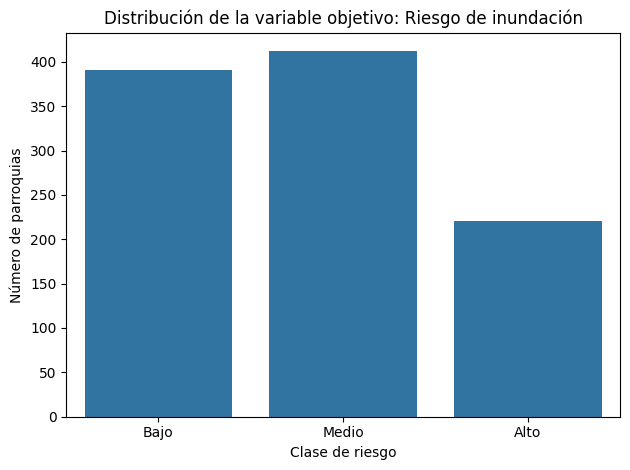

In [8]:
ax = sns.countplot(data=df_modelo, x="RIESGO_INUNDACION", order=["Bajo","Medio","Alto"])
ax.set_title("Distribución de la variable objetivo: Riesgo de inundación")
ax.set_xlabel("Clase de riesgo")
ax.set_ylabel("Número de parroquias")
plt.tight_layout()
plt.show()

Boxplots por clase

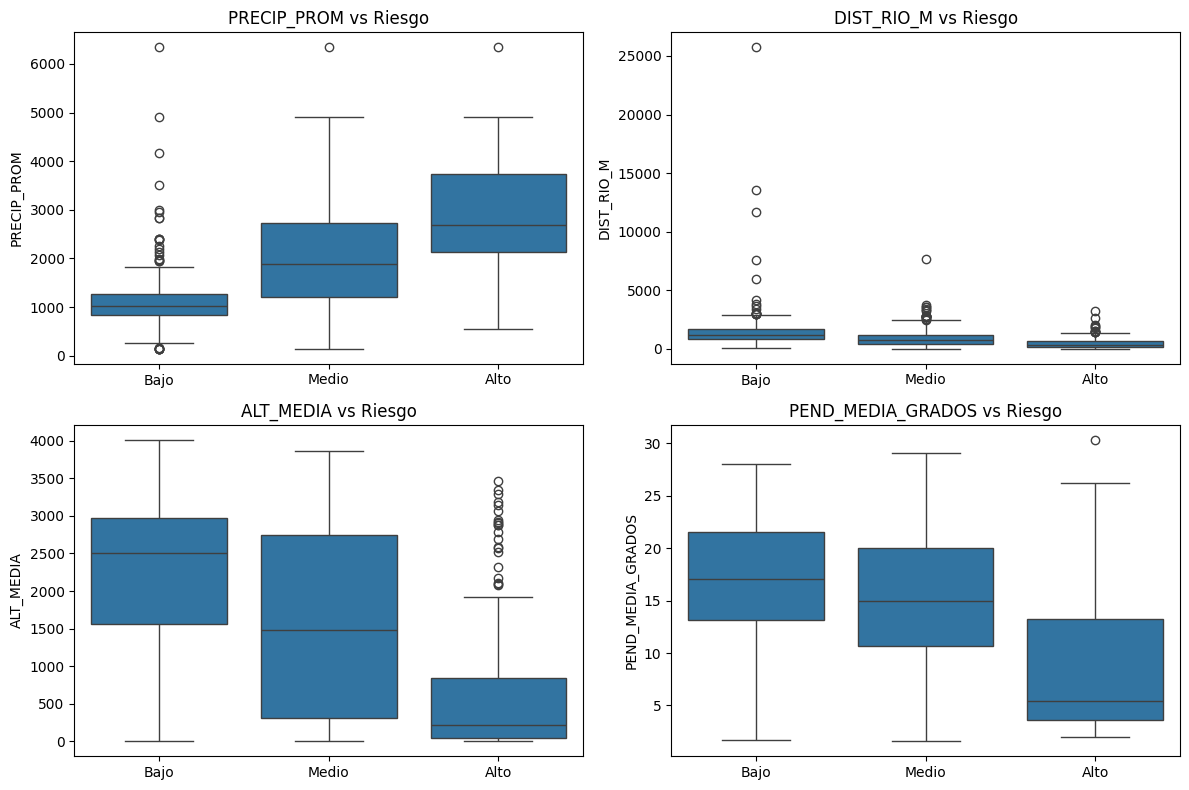

In [9]:
vars_box = ["PRECIP_PROM", "DIST_RIO_M", "ALT_MEDIA", "PEND_MEDIA_GRADOS"]

fig, axs = plt.subplots(2, 2, figsize=(12,8))
axs = axs.ravel()

for i, col in enumerate(vars_box):
    sns.boxplot(data=df_modelo, x="RIESGO_INUNDACION", y=col, ax=axs[i], order=["Bajo","Medio","Alto"])
    axs[i].set_title(f"{col} vs Riesgo")
    axs[i].set_xlabel("")
    axs[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# Correlación

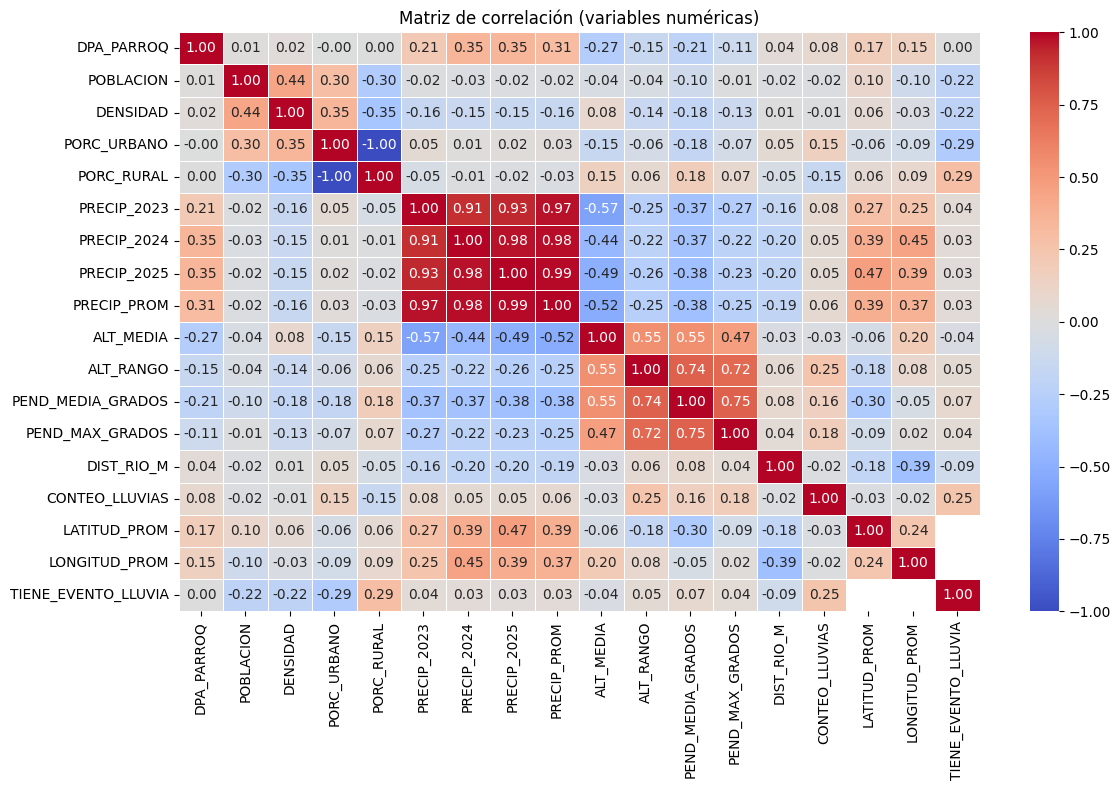

In [10]:
num_cols = df_modelo.select_dtypes(include=["int64","float64"]).columns
plt.figure(figsize=(12,8))
sns.heatmap(df_modelo[num_cols].corr(), cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.4)
plt.title("Matriz de correlación (variables numéricas)")
plt.tight_layout()
plt.show()

# Verificar nulos y duplicados del ultimo dataset

In [11]:
df_modelo.isnull().sum()

PCODE_PARROQ             0
DPA_PARROQ              77
PROVINCIA                0
CANTON                   0
PARROQUIA                0
POBLACION                0
DENSIDAD                 0
PORC_URBANO             42
PORC_RURAL              42
PRECIP_2023              6
PRECIP_2024              6
PRECIP_2025              6
PRECIP_PROM              6
ALT_MEDIA                0
ALT_RANGO               80
PEND_MEDIA_GRADOS        0
PEND_MAX_GRADOS         80
DIST_RIO_M               0
CONTEO_LLUVIAS           0
LATITUD_PROM           116
LONGITUD_PROM          116
TIENE_EVENTO_LLUVIA      0
RIESGO_INUNDACION        0
dtype: int64

In [12]:
columnas_con_nulos = [
    "PORC_URBANO", "PORC_RURAL", 'PRECIP_PROM',
    "ALT_RANGO", "PEND_MAX_GRADOS", "DPA_PARROQ",
    "LATITUD_PROM", "LONGITUD_PROM"
]

for col in columnas_con_nulos:
    df_modelo[col] = df_modelo[col].fillna(df_modelo[col].mean())

In [13]:
df_modelo.isnull().sum()


PCODE_PARROQ           0
DPA_PARROQ             0
PROVINCIA              0
CANTON                 0
PARROQUIA              0
POBLACION              0
DENSIDAD               0
PORC_URBANO            0
PORC_RURAL             0
PRECIP_2023            6
PRECIP_2024            6
PRECIP_2025            6
PRECIP_PROM            0
ALT_MEDIA              0
ALT_RANGO              0
PEND_MEDIA_GRADOS      0
PEND_MAX_GRADOS        0
DIST_RIO_M             0
CONTEO_LLUVIAS         0
LATITUD_PROM           0
LONGITUD_PROM          0
TIENE_EVENTO_LLUVIA    0
RIESGO_INUNDACION      0
dtype: int64

In [14]:
df_modelo.duplicated().sum()

np.int64(0)

# Ejecución de los modelos

In [15]:
features = [
    "PRECIP_PROM",
    "ALT_MEDIA",
    "ALT_RANGO",
    "PEND_MEDIA_GRADOS",
    "PEND_MAX_GRADOS",
    "DIST_RIO_M",
    "LATITUD_PROM",
    "LONGITUD_PROM",
    "POBLACION",
    "DENSIDAD",
    "PORC_URBANO",
    "CONTEO_LLUVIAS",
    "TIENE_EVENTO_LLUVIA"
]

In [16]:
X = df_modelo[features]
y = df_modelo["RIESGO_INUNDACION"]

# Comprobación de balanceo de Dataset

In [17]:
df_modelo["RIESGO_INUNDACION"].value_counts(normalize=True)

RIESGO_INUNDACION
Medio    0.402344
Bajo     0.381836
Alto     0.215820
Name: proportion, dtype: float64

Verificamos la correlación de las variable para ver cuales podemos usar

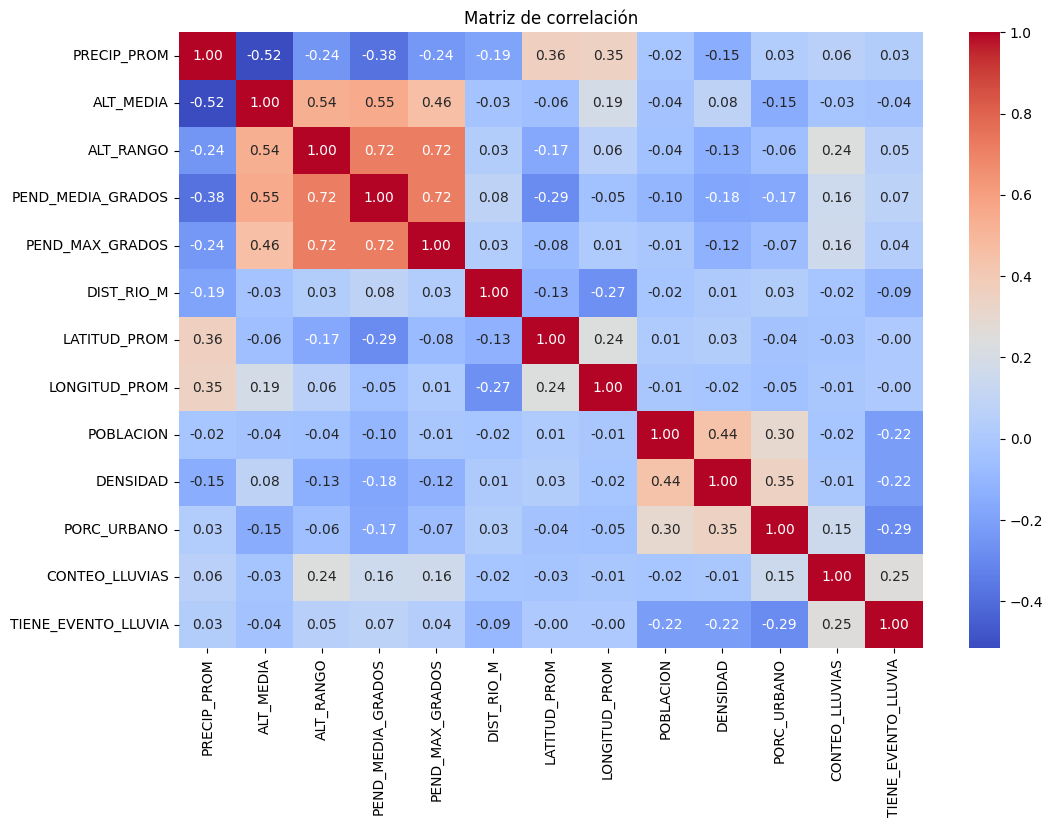

In [18]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(12,8))
sns.heatmap(df_modelo[num_cols].corr(), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

# MODELO 1: Regresión Logística

In [19]:
CLASES = ["Bajo", "Medio", "Alto"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
scaler_rl = StandardScaler()

X_train_scaled = scaler_rl.fit_transform(X_train)
X_test_scaled = scaler_rl.transform(X_test)

In [22]:
modelo_rl = LogisticRegression(
    class_weight="balanced",
    random_state=42
    )
modelo_rl.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [ ]:
pred_rl = modelo_rl.predict(X_test_scaled)

print("=== REGRESIÓN LOGÍSTICA ===")
print(classification_report(y_test, pred_rl, labels=CLASES ))
print("Matriz de confusión:")
print(confusion_matrix(y_test, pred_rl, labels=CLASES))

=== REGRESIÓN LOGÍSTICA ===
              precision    recall  f1-score   support

        Bajo       0.75      0.76      0.75        78
       Medio       0.66      0.59      0.62        83
        Alto       0.71      0.84      0.77        44

    accuracy                           0.71       205
   macro avg       0.71      0.73      0.72       205
weighted avg       0.70      0.71      0.70       205

Matriz de confusión:
[[59 19  0]
 [19 49 15]
 [ 1  6 37]]


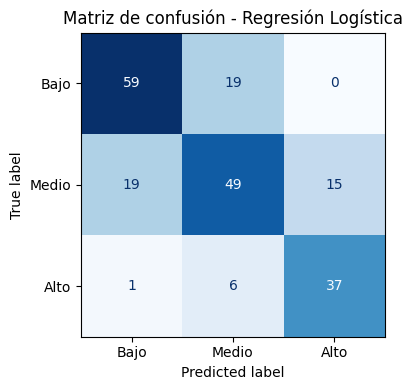

In [24]:
cm = confusion_matrix(y_test, pred_rl, labels=CLASES)
fig, ax = plt.subplots(figsize=(5,4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASES)
disp.plot(ax=ax, values_format="d", cmap="Blues", colorbar=False)
ax.grid(False)
ax.set_title("Matriz de confusión - Regresión Logística")
plt.tight_layout()
plt.show()

# MODELO 2 — ÁRBOL DE DECISIÓN

In [25]:
modelo_dt = DecisionTreeClassifier(random_state=42)
modelo_dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [26]:
pred_dt = modelo_dt.predict(X_test)

print("=== ÁRBOL DE DECISIÓN ===")
print(classification_report(y_test, pred_dt, labels=CLASES))
print("Matriz de confusión:")
print(confusion_matrix(y_test, pred_dt, labels=CLASES))

=== ÁRBOL DE DECISIÓN ===
              precision    recall  f1-score   support

        Bajo       0.97      1.00      0.99        78
       Medio       1.00      0.96      0.98        83
        Alto       0.98      1.00      0.99        44

    accuracy                           0.99       205
   macro avg       0.98      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

Matriz de confusión:
[[78  0  0]
 [ 2 80  1]
 [ 0  0 44]]


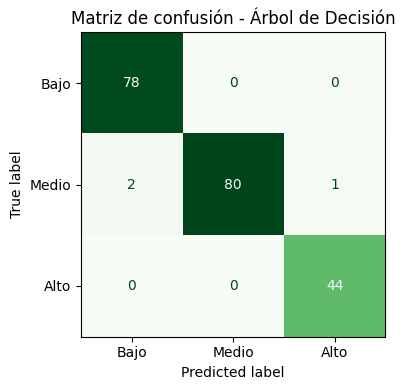

In [27]:
cm_dt = confusion_matrix(y_test, pred_dt, labels=CLASES)

fig, ax = plt.subplots(figsize=(5,4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=CLASES)
disp.plot(ax=ax, values_format="d", cmap="Greens", colorbar=False)

ax.grid(False)
ax.set_title("Matriz de confusión - Árbol de Decisión")

plt.tight_layout()
plt.show()

# MODELO 3 — RANDOM FOREST

In [28]:
modelo_rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)
y_proba = modelo_rf.predict_proba(X_test)

print("=== RANDOM FOREST ===")
print(classification_report(y_test, pred_rf, labels=CLASES))
print("Matriz de confusión:")
print(confusion_matrix(y_test, pred_rf, labels=CLASES))
print("AUC Score:", roc_auc_score(y_test, y_proba, multi_class="ovo"))

=== RANDOM FOREST ===
              precision    recall  f1-score   support

        Bajo       0.97      0.99      0.98        78
       Medio       0.99      0.98      0.98        83
        Alto       1.00      1.00      1.00        44

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

Matriz de confusión:
[[77  1  0]
 [ 2 81  0]
 [ 0  0 44]]
AUC Score: 0.999751336347722


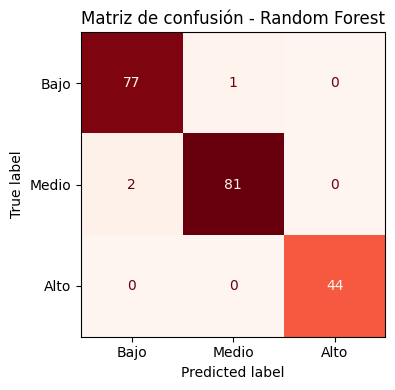

In [29]:
cm_rf = confusion_matrix(y_test, pred_rf, labels=CLASES)

fig, ax = plt.subplots(figsize=(5,4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=CLASES)
disp.plot(ax=ax, values_format="d", cmap="Reds", colorbar=False)

ax.grid(False)
ax.set_title("Matriz de confusión - Random Forest")

plt.tight_layout()
plt.show()

In [30]:
importances = modelo_rf.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)
print(feature_importance_df)

                Feature  Importance
0           PRECIP_PROM    0.258276
5            DIST_RIO_M    0.257356
1             ALT_MEDIA    0.092850
3     PEND_MEDIA_GRADOS    0.088021
11       CONTEO_LLUVIAS    0.050629
2             ALT_RANGO    0.046916
7         LONGITUD_PROM    0.045326
9              DENSIDAD    0.033807
12  TIENE_EVENTO_LLUVIA    0.033744
4       PEND_MAX_GRADOS    0.033321
6          LATITUD_PROM    0.031229
8             POBLACION    0.019891
10          PORC_URBANO    0.008635


## Optimizar Random Forest

In [31]:
param_grid_rf = {
    "n_estimators": [200, 300, 400],
    "max_depth": [3, 5, 6, 9, 12, None],
    "min_samples_split": [2, 5, 7,  10],
    "min_samples_leaf": [1, 3, 5],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid_rf,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Mejores parámetros RF:", grid_rf.best_params_)
print("Mejor F1_macro (CV):", grid_rf.best_score_)

modelo_opt = grid_rf.best_estimator_

pred_opt = modelo_opt.predict(X_test)

print("\n=== RANDOM FOREST OPTIMIZADO ===")
print(classification_report(y_test, pred_opt, labels=CLASES))
print("Matriz de confusión:")
print(confusion_matrix(y_test, pred_opt, labels=CLASES))

Mejores parámetros RF: {'max_depth': 9, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Mejor F1_macro (CV): 0.9742549956526295

=== RANDOM FOREST OPTIMIZADO ===
              precision    recall  f1-score   support

        Bajo       0.97      0.99      0.98        78
       Medio       0.99      0.98      0.98        83
        Alto       1.00      1.00      1.00        44

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

Matriz de confusión:
[[77  1  0]
 [ 2 81  0]
 [ 0  0 44]]


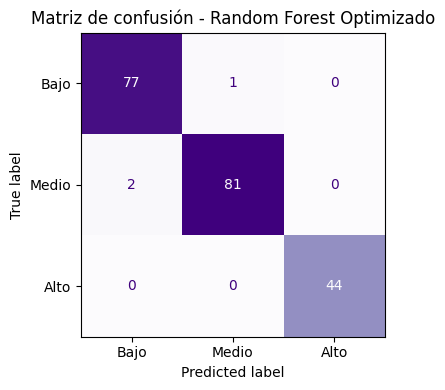

In [33]:
cm_opt = confusion_matrix(y_test, pred_opt, labels=CLASES)

fig, ax = plt.subplots(figsize=(5,4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=CLASES)
disp.plot(ax=ax, values_format="d", cmap="Purples", colorbar=False)

ax.grid(False)
ax.set_title("Matriz de confusión - Random Forest Optimizado")

plt.tight_layout()
plt.show()

# ENSAMBLE

In [ ]:
# Crear DataFrame con las predicciones
votos = pd.DataFrame({
    "RL": pred_rl,
    "DT": pred_dt,
    "RF": pred_rf
})

# Obtener la moda por fila
pred_ens = votos.mode(axis=1)[0]

print("=== ENSAMBLE (RL + DT + RF) ===")
print(classification_report(y_test, pred_ens, labels=CLASES))
print("Matriz de confusión:")
print(confusion_matrix(y_test, pred_ens, labels=CLASES))


=== ENSAMBLE (RL + DT + RF) ===
              precision    recall  f1-score   support

        Bajo       0.97      0.99      0.98        78
       Medio       0.99      0.96      0.98        83
        Alto       0.98      1.00      0.99        44

    accuracy                           0.98       205
   macro avg       0.98      0.98      0.98       205
weighted avg       0.98      0.98      0.98       205

Matriz de confusión:
[[77  1  0]
 [ 2 80  1]
 [ 0  0 44]]


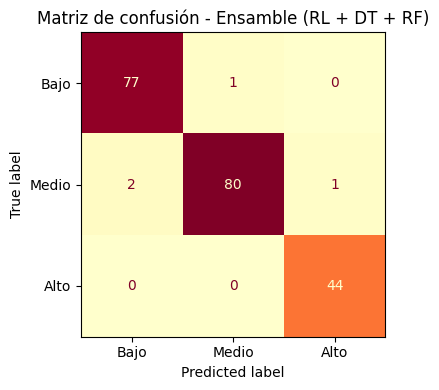

In [35]:
cm_ens = confusion_matrix(y_test, pred_ens, labels=CLASES)

fig, ax = plt.subplots(figsize=(5,4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ens, display_labels=CLASES)
disp.plot(ax=ax, values_format="d", cmap="YlOrRd", colorbar=False)

ax.grid(False)
ax.set_title("Matriz de confusión - Ensamble (RL + DT + RF)")

plt.tight_layout()
plt.show()

Se implementó un ensamble combinando Regresión Logística, Árbol de Decisión y Random Forest mediante voto mayoritario. Aunque el ensamble mejoró el desempeño respecto a los modelos individuales más simples, no logró superar al Random Forest base, el cual presentó el mejor equilibrio entre precisión y recall en las tres clases.

# SVM

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo_svm = SVC(kernel="rbf", C=1, gamma="scale")

modelo_svm.fit(X_train_scaled, y_train)

pred_svm = modelo_svm.predict(X_test_scaled)

print("=== SVM ===")
print(classification_report(y_test, pred_svm))

=== SVM ===
              precision    recall  f1-score   support

        Alto       0.84      0.82      0.83        44
        Bajo       0.85      0.82      0.84        78
       Medio       0.75      0.78      0.76        83

    accuracy                           0.80       205
   macro avg       0.81      0.81      0.81       205
weighted avg       0.81      0.80      0.81       205



Se evaluó adicionalmente un modelo SVM con kernel RBF. Aunque presentó mejor desempeño que la Regresión Logística y el Árbol de Decisión, no superó al Random Forest en términos de F1 macro y accuracy global, por lo que este último fue seleccionado como modelo final.

# COMPARACIÓN: RL vs DT vs Modelo Optimizado

In [ ]:
acc_rl = accuracy_score(y_test, pred_rl)
f1_rl  = f1_score(y_test, pred_rl, average="macro")

acc_dt = accuracy_score(y_test, pred_dt)
f1_dt  = f1_score(y_test, pred_dt, average="macro")

# ===== Métricas RF BASE =====
pred_rf_base = modelo_rf.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf_base)
f1_rf  = f1_score(y_test, pred_rf_base, average="macro")

acc_opt = accuracy_score(y_test, pred_opt)
f1_opt  = f1_score(y_test, pred_opt, average="macro")

tabla = pd.DataFrame({
    "Accuracy": [acc_rl, acc_dt, acc_rf, acc_opt],
    "F1_macro": [f1_rl, f1_dt, f1_rf, f1_opt]
}, index=["RL (base)", "DT", "RF (base)", "Modelo optimizado (RF)"])

print("\n=== COMPARACIÓN FINAL ===")
print(tabla)


=== COMPARACIÓN FINAL ===
                        Accuracy  F1_macro
RL (base)               0.707317  0.715543
DT                      0.985366  0.985900
RF (base)               0.985366  0.987570
Modelo optimizado (RF)  0.985366  0.987570


# Curvas ROC

### Random Forest

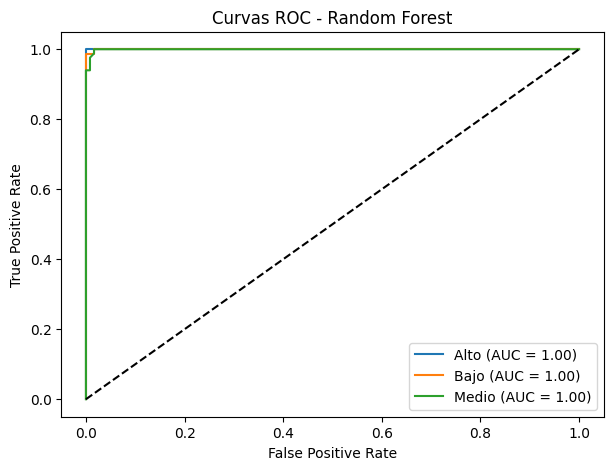

AUC macro (RF): 0.9997187300834574


In [ ]:
clases = modelo_rf.classes_

y_test_bin = label_binarize(y_test, classes=clases)
y_proba = modelo_rf.predict_proba(X_test)

plt.figure(figsize=(7,5))

for i, clase in enumerate(clases):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{clase} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC - Random Forest")
plt.legend()
plt.show()

# AUC promedio
auc_macro_rf = roc_auc_score(y_test_bin, y_proba, average="macro", multi_class="ovr")
print("AUC macro (RF):", auc_macro_rf)

### Regresión Logística

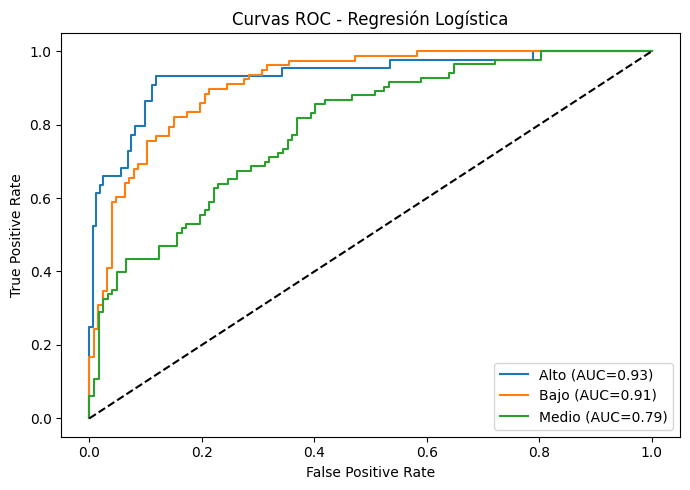

AUC macro (RL): 0.8799135418398233


In [46]:
clases = modelo_rl.classes_

y_test_bin = label_binarize(y_test, classes=clases)

# Probabilidades
proba_rl = modelo_rl.predict_proba(X_test_scaled)

# Curvas ROC por clase
plt.figure(figsize=(7,5))
for i, c in enumerate(clases):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba_rl[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{c} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("Curvas ROC - Regresión Logística")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

# AUC promedio 
auc_macro_rl = roc_auc_score(y_test_bin, proba_rl, average="macro", multi_class="ovr")
print("AUC macro (RL):", auc_macro_rl)

### Árbol de Decisión

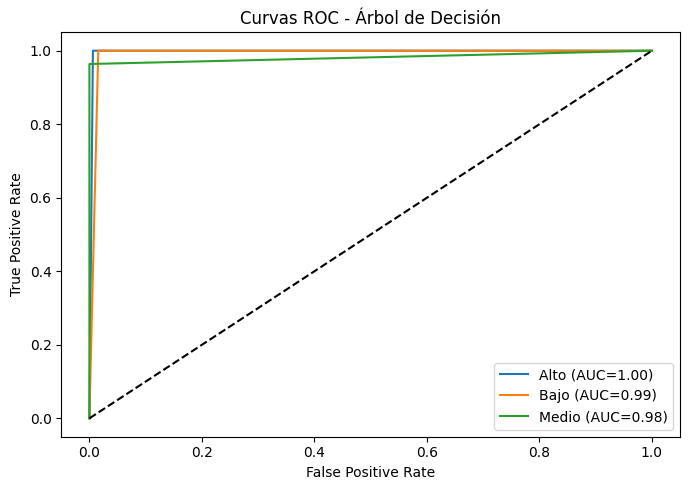

AUC macro (DT): 0.9903160350110767


In [40]:
clases = modelo_dt.classes_
y_test_bin = label_binarize(y_test, classes=clases)

proba_dt = modelo_dt.predict_proba(X_test)

plt.figure(figsize=(7,5))
for i, c in enumerate(clases):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba_dt[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{c} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("Curvas ROC - Árbol de Decisión")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

auc_macro_dt = roc_auc_score(y_test_bin, proba_dt, average="macro", multi_class="ovr")
print("AUC macro (DT):", auc_macro_dt)


# Evaluación de resultados

# Creación de "predicciones.csv"

Las predicciones del modelo fueron exportadas a un archivo predicciones.csv, que incluye el código oficial de parroquia (DPA_PARROQ), la clase de riesgo y el score de confianza.

El emparejamiento con los datos geográficos se realizó utilizando el código de parroquia (DPA_PARROQ) como clave principal, garantizando una unión exacta entre las predicciones y el shapefile.

In [ ]:
X_all = df_modelo[features]

# Escogimos el modelo RF
modelo = modelo_rf  

# Predicción de clase
y_pred = modelo.predict(X_all)

# Score
proba = modelo.predict_proba(X_all)
score = proba.max(axis=1)

df_pred = pd.DataFrame({
    "DPA_PARROQ": df_modelo["DPA_PARROQ"].astype(str).str.strip(),
    "RIESGO_INUNDACION": y_pred,
    "SCORE": np.round(score, 4)
})

df_pred.to_csv("../data/predicciones.csv", index=False, encoding="utf-8-sig")
df_pred.head()

,DPA_PARROQ,RIESGO_INUNDACION,SCORE
0,10151.0,Medio,0.91
1,10153.0,Medio,0.96
2,10154.0,Bajo,0.99
3,10155.0,Medio,0.94
4,10150.0,Bajo,0.96


# Evaluación de los modelos

Se evaluaron los modelos utilizando precisión, recall, F1-score y AUC para las tres clases de riesgo (Bajo, Medio y Alto).

* La Regresión Logística presentó un desempeño aceptable, con una accuracy aproximada de 0.71. Aunque logró un buen recall en la clase “Alto” (0.84), mostró menor capacidad para identificar correctamente la clase “Medio”, reflejado en un F1-score más bajo y un AUC de 0.79 para esa categoría. En general, su capacidad de discriminación fue adecuada, pero inferior a los modelos basados en árboles.

* El Árbol de Decisión mostró un desempeño significativamente superior, con métricas cercanas a 0.99 en precisión, recall y F1-score. Sus curvas ROC se ubicaron muy próximas a la esquina superior izquierda, con valores AUC entre 0.98 y 1.00, indicando una excelente capacidad de separación entre clases. Sin embargo, al tratarse de un único árbol, puede ser más sensible al sobreajuste.

* El Random Forest obtuvo el mejor desempeño global. Presentó accuracy cercana a 0.99 y valores muy altos de precisión, recall y F1-score en todas las clases. En particular, alcanzó recall igual a 1.00 en la clase “Alto”, lo que implica que identificó correctamente todas las parroquias con mayor nivel de riesgo en el conjunto de prueba. Además, las curvas ROC mostraron AUC prácticamente igual a 1.00 para todas las clases, evidenciando una excelente capacidad de discriminación.

##### Posteriormente, se realizó una optimización a RF mediante GridSearchCV, probando diferentes combinaciones de parámetros como número de árboles, profundidad máxima y tamaño mínimo de muestras. Aun evaluando múltiples configuraciones, el modelo mantuvo un desempeño muy alto y estable, confirmando su capacidad de generalización.

* El modelo Ensamble y el SVM también mostraron buenos resultados, pero no superaron el rendimiento global del Random Forest optimizado.

## Modelo seleccionado

El modelo final elegido fue el Random Forest base, ya que presentó un desempeño excelente y estable sin necesidad de ajustes adicionales complejos.

Además, mostró un alto recall en la clase “Alto”, lo cual es fundamental en la gestión del riesgo de inundación por parroquia, ya que minimiza la probabilidad de no identificar zonas realmente vulnerables.

Por su rendimiento, estabilidad y simplicidad, fue el modelo utilizado para generar las predicciones finales del proyecto.

# CONCLUSIÓN TÉCNICA DEL PROYECTO

En este proyecto se desarrolló un modelo de clasificación para estimar el nivel de riesgo de inundación a nivel de parroquia, integrando información demográfica, climática, topográfica e histórica. El proceso incluyó la limpieza y normalización de múltiples fuentes de datos (INEC, precipitación, topografía, ríos y eventos históricos), la construcción de variables derivadas relevantes y la definición de una variable objetivo basada en criterios físicos e hidrológicos.

Se incorporaron variables clave como precipitación promedio, distancia mínima a ríos, altitud media, rango altitudinal, pendiente media y máxima, densidad poblacional, porcentaje urbano y presencia de eventos históricos de lluvia. Estas variables permiten representar tanto la exposición física como la vulnerabilidad territorial de cada parroquia.

Se evaluaron distintos modelos de clasificación (Regresión Logística, Árbol de Decisión, Random Forest, Ensamble y SVM), utilizando métricas como precisión, recall, F1-score y AUC. Los resultados mostraron que los modelos basados en árboles superaron claramente a la Regresión Logística en capacidad de discriminación. El Random Forest obtuvo el mejor desempeño global, con valores de AUC cercanos a 1.00 y un recall de 1.00 en la clase de mayor riesgo, lo cual es fundamental en contextos de gestión del riesgo.

Finalmente, se seleccionó el Random Forest base como modelo final, debido a su alto rendimiento, estabilidad y capacidad para identificar correctamente parroquias con riesgo alto. El modelo permitió generar predicciones finales con un score de confianza asociado, listas para su integración en herramientas de visualización o apoyo a la toma de decisiones.

En términos técnicos, el proyecto demuestra que la integración de variables geoespaciales, climáticas y socio-demográficas, combinada con modelos de ensamble robustos, constituye una estrategia efectiva para la estimación territorial del riesgo de inundación.